#### Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Load Dataset

In [9]:
path = r"https://drive.google.com/uc?export=download&id=13ZTYmL3E8S0nz-UKl4aaTZJaI3DVBGHM"
df = pd.read_csv(path)
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [11]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


#### Data Cleaning

In [12]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

##### Missing value percentage

In [14]:
missing_percentage = df.isnull().mean() * 100
print(missing_percentage)

study_hours      2.5
student_marks    0.0
dtype: float64


##### check duplicate record

In [15]:
df.duplicated().sum()

np.int64(0)

##### Fill record with mean

In [17]:
mean_study_hours = df['study_hours'].mean()
print(mean_study_hours)

6.9959487179487185


In [18]:
df['study_hours'] = df['study_hours'].fillna(mean_study_hours)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    200 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


#### We will perform EDA

##### Distribution of Study Hours

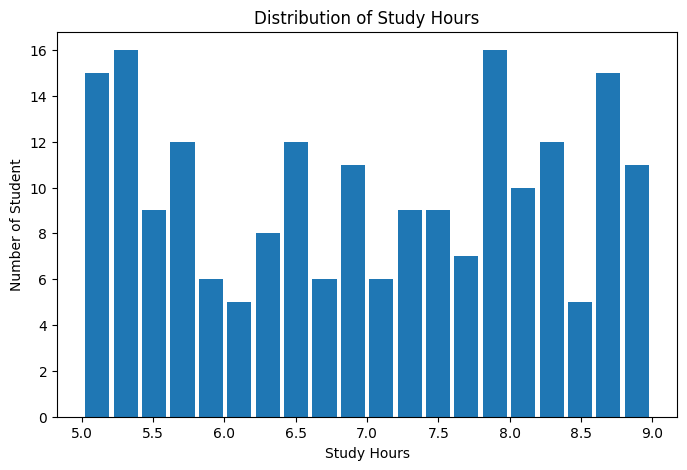

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['study_hours'], bins=20, rwidth=0.85)
plt.xlabel('Study Hours')
plt.ylabel('Number of Student')
plt.title("Distribution of Study Hours")
plt.show()

##### Distribution of Marks

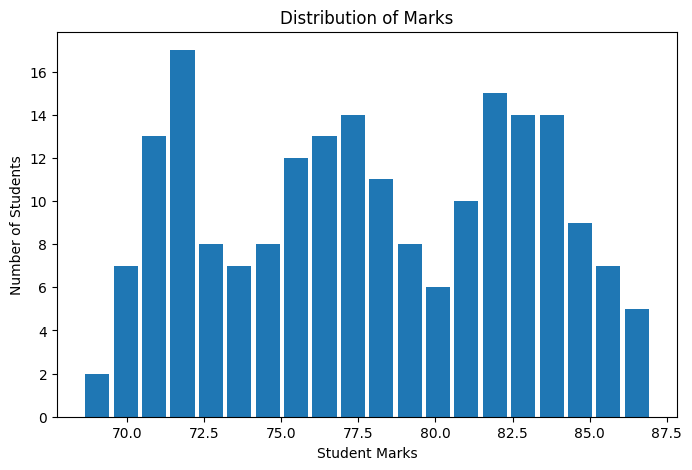

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df['student_marks'],bins=20, rwidth=0.85)
plt.xlabel('Student Marks')
plt.ylabel('Number of Students')
plt.title('Distribution of Marks')
plt.show()

##### Showing relationship between student marks and student hours in scatter plot

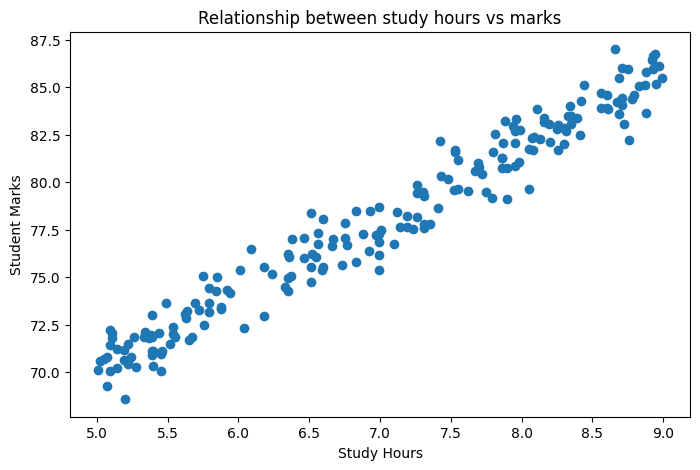

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['study_hours'],
    df['student_marks']
)
plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.title("Relationship between study hours vs marks")
plt.show()

#### Correlation Analysis

In [29]:
df[['study_hours','student_marks']].corr()

,study_hours,student_marks
study_hours,1.000000,0.978696
student_marks,0.978696,1.000000


###### As per corr relation, There is strong positive relation between student study hours vs marks, if student study more, he will get more marks

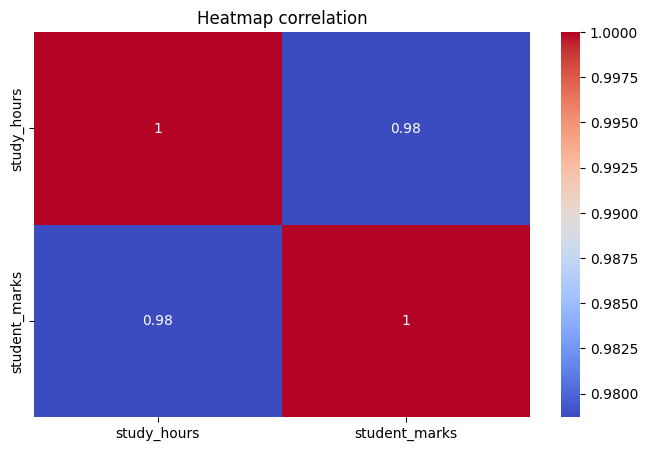

In [30]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap correlation")
plt.show()

### Split Feature Dataset

In [51]:
X = df[['study_hours']]
y = df['student_marks']

In [52]:
print("X shape: ",X.shape)
print("Y shape: ",y.shape)

X shape:  (200, 1)
Y shape:  (200,)


##### Train/Test Split

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state= 0)

In [55]:
len(X_train)

160

In [56]:
len(X_test)

40

#### Linear Regression

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [58]:
lr = LinearRegression()

In [59]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
y_pred = lr.predict(X_test)
print(y_pred)

[83.50507271 70.84927186 72.93236952 85.35234799 73.20749562 84.48766595
 80.12495199 81.85431608 80.91102657 82.20804964 78.98514384 84.84139951
 77.84533568 77.68812077 83.22994661 85.78468901 84.9593107  72.61793968
 78.71001773 79.18166248 84.2911473  85.6274741  74.74034107 81.3433676
 72.02838374 80.40007809 78.98514384 82.09013845 77.94732382 82.24735337
 75.44780819 84.60557713 71.63534645 75.48711192 70.29901965 78.98514384
 75.32989701 84.52696967 74.07217767 71.4388278 ]


In [65]:
lr.predict([[11]])[0].round(2)

C:\Users\icons\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(93.68)

In [67]:
lr.predict([[11],[4],[8]]).round(2)

C:\Users\icons\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([93.68, 66.17, 81.89])

#### Comparision of actual and predicted

In [70]:
pd.DataFrame(np.c_[X_test,y_test,y_pred], columns=["Study Hours","Actual Marks","Predicted Marks"])

,Study Hours,Actual Marks,Predicted Marks
0,8.410000,82.50,83.505073
1,5.190000,71.18,70.849272
2,5.720000,73.25,72.932370
3,8.880000,83.64,85.352348
4,5.790000,73.64,73.207496
5,8.660000,86.99,84.487666
6,7.550000,81.18,80.124952
7,7.990000,82.75,81.854316
8,7.750000,79.50,80.911027
9,8.080000,81.70,82.208050


#### Evaluate the Model

In [71]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("mse", mse)

mse 1.0443968573561397


In [79]:
'''root mean square error'''
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1.021957365723316


In [78]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", round(r2, 4))

R² Score: 0.9522


#### Visualize Regression Line

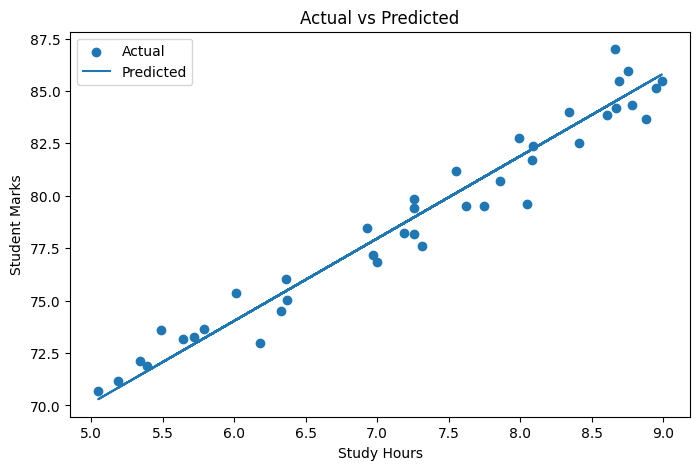

In [80]:
plt.figure(figsize=(8,5))
plt.scatter(
    X_test,
    y_test,
    label="Actual"
)

plt.plot(
    X_test,
    y_pred,
    label="Predicted"
)

plt.xlabel("Study Hours")
plt.ylabel("Student Marks")
plt.title("Actual vs Predicted")

plt.legend()
plt.show()

### Save Model

In [82]:
import joblib

In [83]:
joblib.dump(lr,"student_marks_model.pkl")

['student_marks_model.pkl']

#### Load the Model

In [84]:
model = joblib.load("student_marks_model.pkl")

In [85]:
print(model)

LinearRegression()


In [89]:
prediction = model.predict([[6]])
print(prediction)

[74.03287394]


C:\Users\icons\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
